# Olist Delivery Delay Prediction
### Brazilian E-Commerce Public Dataset | Capstone Project
#### Notebook: Data Understanding and Cleaning

---

**Authors:** Sura and Aman

**Verified by:** Ameed and Ruaa

**Dataset:** [Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)

**Tracks:** Supervised Learning (Binary Classification) · Unsupervised Learning (Clustering)

---

## Problem Statement

**Late deliveries** damage customer trust, increase support costs, and lead to negative reviews.

**Business question:** Can we predict whether an order will be delivered late,
before it ships, so Olist can proactively manage at-risk orders?

**Stakeholder:** Olist Operations and Customer Experience Team


---

## Data Understanding

### How Olist works and how the data was captured

Olist is the largest department store in Brazilian marketplaces. It connects small 
businesses from all over Brazil to multiple sales channels through a single contract. 
Merchants sell their products through the Olist Store and ship them directly to 
customers using Olist's logistics partners.

After a customer purchases a product, the seller is notified to fulfill the order. 
Once the customer receives the product, or the estimated delivery date is due, 
the customer receives a satisfaction survey by email to rate the purchase experience 
and leave comments.

This dataset contains 100,000 orders made between 2016 and 2018 across multiple 
marketplaces in Brazil. It allows viewing each order from multiple dimensions: 
order status, price, payment, freight performance, customer location, product 
attributes, and customer reviews. The data is real but has been anonymised for 
public release.

<div align="center">
  <img src="https://raw.githubusercontent.com/Ameed2/capstone-project3/Sura/assets/olist_flow.jpg" width="850px">
  <br>
  <p style="color: grey; font-style: italic;">
    Figure 1: Olist E-Commerce Data Lifecycle & Pipeline
  </p>
</div>

---

### Important Considerations
 As per the dataset documentation and marketplace architecture...
* **Order Composition:** An order might have multiple items.
* **Fulfillment:** Each item might be fulfilled by a distinct seller.
* **Anonymization:** All text identifying stores and partners were replaced by the names of **Game of Thrones** great houses.

---

### Contextual Reference
To better understand how the data was captured at the source, the following is an example of a live product listing on the marketplace:

<div align="center">
  <img src="https://raw.githubusercontent.com/Ameed2/capstone-project3/Sura/assets/product_listing_example.png" width="600px">
  <br>
  <p style="color: grey; font-style: italic;">
    Figure 2: Example of a Product Listing on the Marketplace
  </p>
</div>



---
## Data Schema & Relationships
The dataset consists of multiple tables linked through unique identifiers. The following schema (ERD) serves as our map for merging and joining data during the cleaning phase.

<div align="center">
  <img src="https://raw.githubusercontent.com/Ameed2/capstone-project3/Sura/assets/olist_data_schema.jpg" width="850px">
  <br>
  <p style="color: grey; font-style: italic;">
    Figure 3: Interconnected Olist Data Schema (ERD)
  </p>
</div>

---

## Setup and Imports

In [22]:
# ── Libraries ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# ── Display Settings ─────────────────────────────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

warnings.filterwarnings('ignore')

## Dataset Overview

The dataset consists of 9 CSV files. Each file represents a different 
dimension of the order lifecycle.

In [23]:
# ── Olist E-Commerce Dataset - Data Loading ─────────────────────────────────────────────────────────

# Define path to raw data
DATA_PATH = '../data/raw/'

# Load all tables
orders      = pd.read_csv(DATA_PATH + 'olist_orders_dataset.csv')
items       = pd.read_csv(DATA_PATH + 'olist_order_items_dataset.csv')
payments    = pd.read_csv(DATA_PATH + 'olist_order_payments_dataset.csv')
reviews     = pd.read_csv(DATA_PATH + 'olist_order_reviews_dataset.csv')
customers   = pd.read_csv(DATA_PATH + 'olist_customers_dataset.csv')
sellers     = pd.read_csv(DATA_PATH + 'olist_sellers_dataset.csv')
products    = pd.read_csv(DATA_PATH + 'olist_products_dataset.csv')
geolocation = pd.read_csv(DATA_PATH + 'olist_geolocation_dataset.csv')
translation = pd.read_csv(DATA_PATH + 'product_category_name_translation.csv')

# Print shape of each
tables = {
    'orders'      : orders,
    'items'       : items,
    'payments'    : payments,
    'reviews'     : reviews,
    'customers'   : customers,
    'sellers'     : sellers,
    'products'    : products,
    'geolocation' : geolocation,
    'translation' : translation
}

for name, df in tables.items():
    print(f"{name:15} {df.shape[0]:>10,} rows | {df.shape[1]:>2} columns")

orders              99,441 rows |  8 columns
items              112,650 rows |  7 columns
payments           103,886 rows |  5 columns
reviews             99,224 rows |  7 columns
customers           99,441 rows |  5 columns
sellers              3,095 rows |  4 columns
products            32,951 rows |  9 columns
geolocation      1,000,163 rows |  5 columns
translation             71 rows |  2 columns




| File | Rows | Columns | One row represents |
|------|------|---------|--------------------|
| olist_orders_dataset.csv | 99,441 | 8 | One unique order |
| olist_order_items_dataset.csv | 112,650 | 7 | One item within an order |
| olist_order_payments_dataset.csv | 103,886 | 5 | One payment transaction |
| olist_order_reviews_dataset.csv | 99,224 | 7 | One customer review |
| olist_customers_dataset.csv | 99,441 | 5 | One unique customer |
| olist_sellers_dataset.csv | 3,095 | 4 | One unique seller |
| olist_products_dataset.csv | 32,951 | 9 | One unique product |
| olist_geolocation_dataset.csv | 1,000,163 | 5 | One zip code to lat/lng mapping |
| product_category_name_translation.csv | 71 | 2 | One category name translation |



> **Note:** olist_orders_dataset is the central table. 
> All other tables connect to it directly or indirectly through shared keys.

**Key observations:**

- `olist_order_items_dataset` has more rows than `olist_orders_dataset` (112,650 vs 99,441),
  meaning some orders contain multiple items.
- `olist_order_payments_dataset` also exceeds the orders count (103,886 vs 99,441),
  meaning some orders were paid using more than one payment method.

Both cases are expected based on the dataset documentation and will be handled during merging.


---

## Data Dictionary

> Column descriptions are based on the official Olist dataset documentation.

---

### 1. olist_orders_dataset
One row = one unique order.

| Column | Description |
|--------|-------------|
| order_id | Unique identifier of the order |
| customer_id | Key to the customers dataset. Each order has a unique customer_id |
| order_status | Reference to the order status (delivered, shipped, etc) |
| order_purchase_timestamp | Shows the purchase timestamp |
| order_approved_at | Shows the payment approval timestamp |
| order_delivered_carrier_date | Shows the order posting timestamp. When it was handled to the logistic partner |
| order_delivered_customer_date | Shows the actual order delivery date to the customer |
| order_estimated_delivery_date | Shows the estimated delivery date that was informed to customer at the purchase moment |

---

### 2. olist_order_items_dataset
One row = one item within an order.

| Column | Description |
|--------|-------------|
| order_id | Unique identifier of the order |
| order_item_id | Sequential number identifying number of items included in the same order |
| product_id | Product unique identifier |
| seller_id | Seller unique identifier |
| shipping_limit_date | Shows the seller shipping limit date for handling the order over to the logistic partner |
| price | Item price |
| freight_value | Item freight value. If an order has more than one item the freight value is splitted between items |

---

### 3. olist_order_payments_dataset
One row = one payment transaction for an order.

| Column | Description |
|--------|-------------|
| order_id | Unique identifier of an order |
| payment_sequential | A customer may pay an order with more than one payment method. If he does so, a sequence will be created to accommodate all payments |
| payment_type | Method of payment chosen by the customer |
| payment_installments | Number of installments chosen by the customer |
| payment_value | Transaction value |

---

### 4. olist_order_reviews_dataset
One row = one customer review for an order.

| Column | Description |
|--------|-------------|
| review_id | Unique review identifier |
| order_id | Unique order identifier |
| review_score | Note ranging from 1 to 5 given by the customer on a satisfaction survey |
| review_comment_title | Comment title from the review left by the customer, in Portuguese |
| review_comment_message | Comment message from the review left by the customer, in Portuguese |
| review_creation_date | Shows the date in which the satisfaction survey was sent to the customer |
| review_answer_timestamp | Shows satisfaction survey answer timestamp |

---

### 5. olist_customers_dataset
One row = one unique customer.

| Column | Description |
|--------|-------------|
| customer_id | Key to the orders dataset. Each order has a unique customer_id |
| customer_unique_id | Unique identifier of a customer |
| customer_zip_code_prefix | First five digits of customer zip code |
| customer_city | Customer city name |
| customer_state | Customer state |

---

### 6. olist_sellers_dataset
One row = one unique seller.

| Column | Description |
|--------|-------------|
| seller_id | Seller unique identifier |
| seller_zip_code_prefix | First 5 digits of seller zip code |
| seller_city | Seller city name |
| seller_state | Seller state |

---

### 7. olist_products_dataset
One row = one unique product.

| Column | Description |
|--------|-------------|
| product_id | Unique product identifier |
| product_category_name | Root category of product, in Portuguese |
| product_name_lenght | Number of characters extracted from the product name |
| product_description_lenght | Number of characters extracted from the product description |
| product_photos_qty | Number of product published photos |
| product_weight_g | Product weight measured in grams |
| product_length_cm | Product length measured in centimeters |
| product_height_cm | Product height measured in centimeters |
| product_width_cm | Product width measured in centimeters |

---

### 8. olist_geolocation_dataset
One row = one zip code to coordinates mapping.

| Column | Description |
|--------|-------------|
| geolocation_zip_code_prefix | First 5 digits of zip code |
| geolocation_lat | Latitude |
| geolocation_lng | Longitude |
| geolocation_city | City name |
| geolocation_state | State |

---

### 9. product_category_name_translation
One row = one category name translation.

| Column | Description |
|--------|-------------|
| product_category_name | Category name in Portuguese |
| product_category_name_english | Category name in English |

---

### Target Variable

`is_late` will be derived from two columns in this table:
- `is_late = 1` if `order_delivered_customer_date` > `order_estimated_delivery_date`
- `is_late = 0` otherwise

This column will be created after the cleaning step is complete.

---
## Data Preview

In [24]:
# ── Data Preview ─────────────────────────────────────────────────────────────
for name, df in tables.items():
    print(f"\n{'='*60}")
    print(f"  {name}  —  {df.shape[0]:,} rows x {df.shape[1]} columns")
    print(f"{'='*60}")
    print(df.head(3))


  orders  —  99,441 rows x 8 columns
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           2018-08-07 15:27:45   
2          2018-08-08 13:50:00           2018-08-17 18:06:29   

  order_estimated_delivery_date  
0           2017-10-18 00:00:00  
1           2018-08-13 00:00:00  
2           2018-09-04 00:00:00  

  items  —  112,65

### Data Preview

The first 3 rows of each table are displayed above. A few observations:

- All tables loaded correctly with the expected structure.
- Several tables contain date and timestamp columns. Their data types need to be verified
  to ensure they are handled correctly in the analysis.
- `reviews`: `review_comment_title` and `review_comment_message` show NaN values
  from the first rows, confirming missing data in these columns.
- `products`: category names are in Portuguese — will need translation later.
- `geolocation`: first rows all belong to Sao Paulo, which is expected as it is
  the largest city in Brazil.

---
## Understand the data 

In [25]:
# ── Descriptive Statistics (Numeric Columns) ─────────────────────────────────
# Min, Max, Mean, Std, and Quartiles (25%, 50%, 75%) for all numeric columns per table

print("=" * 60)
print("  DESCRIPTIVE STATISTICS SUMMARY")
print("  (count, mean, std, min, 25%, 50%, 75%, max)")
print("=" * 60)

for name, df in tables.items():
    numeric_cols = df.select_dtypes(include='number')
    if numeric_cols.empty:
        print(f"\n {name}: No numeric columns found.")
        continue
    print(f"\n{'='*60}")
    print(f"  {name}  —  {numeric_cols.shape[1]} numeric column(s)")
    print(f"{'='*60}")
    print(numeric_cols.describe().T.to_string())

  DESCRIPTIVE STATISTICS SUMMARY
  (count, mean, std, min, 25%, 50%, 75%, max)

 orders: No numeric columns found.

  items  —  3 numeric column(s)
                  count   mean    std  min   25%   50%    75%     max
order_item_id 112650.00   1.20   0.71 1.00  1.00  1.00   1.00   21.00
price         112650.00 120.65 183.63 0.85 39.90 74.99 134.90 6735.00
freight_value 112650.00  19.99  15.81 0.00 13.08 16.26  21.15  409.68

  payments  —  3 numeric column(s)
                         count   mean    std  min   25%    50%    75%      max
payment_sequential   103886.00   1.09   0.71 1.00  1.00   1.00   1.00    29.00
payment_installments 103886.00   2.85   2.69 0.00  1.00   1.00   4.00    24.00
payment_value        103886.00 154.10 217.49 0.00 56.79 100.00 171.84 13664.08

  reviews  —  1 numeric column(s)
                count  mean  std  min  25%  50%  75%  max
review_score 99224.00  4.09 1.35 1.00 4.00 5.00 5.00 5.00

  customers  —  1 numeric column(s)
                            coun

In [26]:
# ── Data Types and Missing Values per Table ───────────────────────────────────
for name, df in tables.items():
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    missing = df.isnull().sum()
    dtypes = df.dtypes
    summary = pd.DataFrame({'dtype': dtypes, 'missing': missing})
    print(summary)


  orders
                                dtype  missing
order_id                       object        0
customer_id                    object        0
order_status                   object        0
order_purchase_timestamp       object        0
order_approved_at              object      160
order_delivered_carrier_date   object     1783
order_delivered_customer_date  object     2965
order_estimated_delivery_date  object        0

  items
                       dtype  missing
order_id              object        0
order_item_id          int64        0
product_id            object        0
seller_id             object        0
shipping_limit_date   object        0
price                float64        0
freight_value        float64        0

  payments
                        dtype  missing
order_id               object        0
payment_sequential      int64        0
payment_type           object        0
payment_installments    int64        0
payment_value         float64        0

  revie

## Initial Exploration

After loading all tables, two issues were found:

### 1. Data Types
All timestamp columns were read as `object` instead of `datetime`. This affects:
- `orders`: order_purchase_timestamp, order_approved_at, order_delivered_carrier_date,
  order_delivered_customer_date, order_estimated_delivery_date
- `items`: shipping_limit_date
- `reviews`: review_creation_date, review_answer_timestamp


---
### Data Type Fixes

In [27]:
# ── Data Type Fixes ───────────────────────────────────────────────────────────
# Convert all timestamp columns from object to datetime

# orders
orders['order_purchase_timestamp']      = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_approved_at']             = pd.to_datetime(orders['order_approved_at'])
orders['order_delivered_carrier_date']  = pd.to_datetime(orders['order_delivered_carrier_date'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

# items
items['shipping_limit_date'] = pd.to_datetime(items['shipping_limit_date'])

# reviews
reviews['review_creation_date']    = pd.to_datetime(reviews['review_creation_date'])
reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'])

print("Done. Verifying dtypes:")
print(orders[['order_purchase_timestamp', 'order_delivered_customer_date']].dtypes)

Done. Verifying dtypes:
order_purchase_timestamp         datetime64[ns]
order_delivered_customer_date    datetime64[ns]
dtype: object


All timestamp columns successfully converted from `object` to `datetime64`.
Date calculations are now possible.

---
### 2. Missing Values Identification

In [28]:
# ── Scan all tables for missing values ─────────────────────────────────────

for name, df in tables.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f"\nMissing values in: {name}")
        print(missing.to_string())


Missing values in: orders
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965

Missing values in: reviews
review_comment_title      87656
review_comment_message    58247

Missing values in: products
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2


### Handling Missing Values (Intentional Removal)

In [29]:
# Handling Orders: Keep only completed delivery cycles
initial_orders = len(orders)
orders = orders.dropna(subset=['order_delivered_customer_date', 'order_approved_at', 'order_delivered_carrier_date'])

# Handling Reviews & Products
reviews['review_comment_message'] = reviews['review_comment_message'].fillna('no_comment')
products['product_category_name'] = products['product_category_name'].fillna('unknown')
products = products.dropna(subset=['product_weight_g'])

print(f" Missing values handled. Orders retained: {len(orders)} ({initial_orders - len(orders)} dropped).")

 Missing values handled. Orders retained: 96461 (2980 dropped).


###  Internal Notes for EDA Team
After the cleaning process, please consider the following insights during your Exploratory Data Analysis:

* **Target Variable:** Use `is_late` as the primary target. Note that we only kept "Delivered" orders with full timestamps to ensure the target calculation is 100% accurate.
* **Review Sentiment:** When analyzing customer satisfaction, remember that `no_comment` in the message field does **not** mean a neutral review; check the `review_score` for the actual sentiment.
* **Product Categories:** We have introduced an `unknown` category for products with missing names. Please check if these 'unknown' products show any specific patterns regarding delivery delays or freight costs.
* **Data Volume:** We removed ~2,980 incomplete records (~3% of the data). This is a negligible loss that significantly improves our model's reliability by removing "noise".
---

## Comprehensive Duplicate Investigation
Reasoning: Before performing any data reduction, we must audit each table to identify the extent of duplicate records. This allows us to understand if the duplicates are system-wide or isolated to specific datasets (like geolocation).

In [30]:
# ── Audit for Duplicate Rows ──────────────────────────────────────────────────
duplicate_report = []

for name, df in tables.items():
    dup_count = df.duplicated().sum()
    dup_percentage = (dup_count / len(df)) * 100
    duplicate_report.append({
        'Dataset': name,
        'Duplicate Rows': dup_count,
        'Percentage (%)': round(dup_percentage, 2)
    })

# Convert report to DataFrame for a clean display
dup_df = pd.DataFrame(duplicate_report)
print(" Duplicate Audit Report:")
print(dup_df.sort_values(by='Duplicate Rows', ascending=False).to_string(index=False))

 Duplicate Audit Report:
    Dataset  Duplicate Rows  Percentage (%)
geolocation          261831           26.18
     orders               0            0.00
      items               0            0.00
   payments               0            0.00
    reviews               0            0.00
  customers               0            0.00
    sellers               0            0.00
   products               0            0.00
translation               0            0.00


### Duplicate Audit Summary
Transactional Tables: 0 duplicates. All records in orders, items, payments, and products are unique.

Geolocation Table: 261,831 duplicates identified.

### Decision:

Decision: Retained all geolocation records to preserve GPS coordinate precision for distance calculations between sellers and customers.

---

### Logical Consistency & Outlier Audit

In [31]:
# Remove orders delivered before purchase date
delivery_before_purchase = orders[
    orders['order_delivered_customer_date'] < orders['order_purchase_timestamp']
]

print(f"Logical Errors (Delivery < Purchase): {len(delivery_before_purchase)} rows")

if len(delivery_before_purchase) > 0:
    orders = orders.drop(delivery_before_purchase.index)
    print(f"Removed {len(delivery_before_purchase)} logical errors.")
else:
    print("No logical errors found.")

Logical Errors (Delivery < Purchase): 0 rows
No logical errors found.


In [32]:
# Calculate delivery duration in days
orders['delivery_days'] = (
    orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']
).dt.days

print(orders['delivery_days'].describe(percentiles=[.25, .50, .75, .90, .95, .99]))
print(f"\nMax delivery: {orders['delivery_days'].max()} days")

count   96461.00
mean       12.09
std         9.55
min         0.00
25%         6.00
50%        10.00
75%        15.00
90%        23.00
95%        29.00
99%        46.00
max       209.00
Name: delivery_days, dtype: float64

Max delivery: 209 days


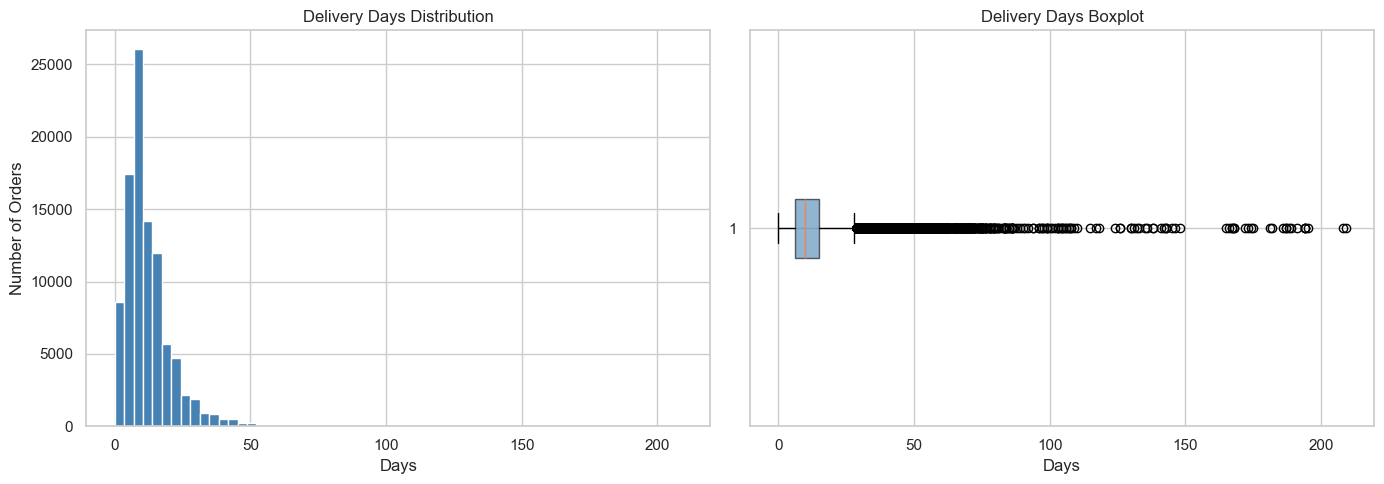

In [33]:
# Visualize distribution to find natural threshold
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(orders['delivery_days'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Delivery Days Distribution')
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Number of Orders')

axes[1].boxplot(orders['delivery_days'].dropna(), vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Delivery Days Boxplot')
axes[1].set_xlabel('Days')

plt.tight_layout()
plt.show()

 The charts above show the full distribution before removal.

In [34]:
# Set outlier threshold using 99th percentile
threshold = orders['delivery_days'].quantile(0.99)
extreme_delivery = orders[orders['delivery_days'] > threshold]

print(f"99th percentile threshold: {threshold:.0f} days")
print(f"Extreme outliers above threshold: {len(extreme_delivery)} rows")
print(f"Percentage of total orders: {len(extreme_delivery) / len(orders) * 100:.2f}%")

99th percentile threshold: 46 days
Extreme outliers above threshold: 879 rows
Percentage of total orders: 0.91%


In [35]:
orders['is_late'] = (
    orders['order_delivered_customer_date'] > orders['order_estimated_delivery_date']
).astype(int)

In [36]:
# ── Checking outliers before removal ──────────────────────────────
extreme_delivery = orders[orders['delivery_days'] > threshold]

print("=== Composition of the 879 removed orders ===")
print(extreme_delivery['is_late'].value_counts())
print()
print(extreme_delivery['is_late'].value_counts(normalize=True).mul(100).round(1))

=== Composition of the 879 removed orders ===
is_late
1    848
0     31
Name: count, dtype: int64

is_late
1   96.50
0    3.50
Name: proportion, dtype: float64


###  Finding

96.5% of the orders flagged as outliers (`delivery_days > 46`) are **confirmed late deliveries** — not data anomalies.
These represent the hardest real-world cases the model needs to learn from.

---

###  Decision: Retain All Orders Above the 46-Day Threshold

Removing these 879 orders would introduce the following problems:

| # | Problem | Impact |
|---|---------|--------|
| 1 | Strip 848 confirmed late cases from training data | Model never sees extreme delays |
| 2 | Artificially deflate late delivery rate from ~8.1% → 7.3% | Distorted class balance |
| 3 | Bias the model toward short, easy deliveries | Poor generalization |
| 4 | Lose the hardest high-risk cases entirely | Reduced business value |

---

###  Conclusion

These orders are **statistically extreme** in `delivery_days`,
but they are **business-critical** for our prediction target `is_late`.

> Outlier treatment for `delivery_days` will be deferred to the **Feature Engineering** phase,
> where techniques such as **capping** or **log-transformation** will be applied at the feature level —
> not by removing rows here.

---

In [37]:
# ── Outlier Check: items ──────────────────────────────────────────────────────

print(items[['price', 'freight_value']].describe(percentiles=[.25, .50, .75, .90, .95, .99]))

          price  freight_value
count 112650.00      112650.00
mean     120.65          19.99
std      183.63          15.81
min        0.85           0.00
25%       39.90          13.08
50%       74.99          16.26
75%      134.90          21.15
90%      229.80          34.04
95%      349.90          45.12
99%      890.00          84.52
max     6735.00         409.68


freight_value = 0: needs investigation in EDA (free shipping or error?)

In [38]:
# ── Outlier Check: payments ───────────────────────────────────────────────────

print(payments[['payment_value']].describe(percentiles=[.25, .50, .75, .90, .95, .99]))

       payment_value
count      103886.00
mean          154.10
std           217.49
min             0.00
25%            56.79
50%           100.00
75%           171.84
90%           297.27
95%           437.63
99%          1039.92
max         13664.08


payment_value = 0: possible coupon orders, flag for EDA

In [39]:
# ── Outlier Check: products ───────────────────────────────────────────────────

print(products[['product_weight_g', 'product_length_cm', 
                'product_height_cm', 'product_width_cm']].describe(
                percentiles=[.25, .50, .75, .90, .95, .99]))

       product_weight_g  product_length_cm  product_height_cm  \
count          32949.00           32949.00           32949.00   
mean            2276.47              30.82              16.94   
std             4282.04              16.91              13.64   
min                0.00               7.00               2.00   
25%              300.00              18.00               8.00   
50%              700.00              25.00              13.00   
75%             1900.00              38.00              21.00   
90%             6300.00              53.00              33.00   
95%            10850.00              65.00              44.00   
99%            22538.00             100.00              69.00   
max            40425.00             105.00             105.00   

       product_width_cm  
count          32949.00  
mean              23.20  
std               12.08  
min                6.00  
25%               15.00  
50%               20.00  
75%               30.00  
90%        

 `product_weight_g = 0` is treated as a data entry error.
 
 Olist is a physical goods marketplace —> all orders require shipping and have carrier records. 
 
 Zero weight is physically impossible for a shipped product and was replaced with the median.

In [40]:
median_weight = products[products['product_weight_g'] > 0]['product_weight_g'].median()
products['product_weight_g'] = products['product_weight_g'].replace(0, median_weight)

### Note
price and payment_value have high-value outliers —> review during modeling

---

In [41]:
# ── Cleaning Summary ─────────────────────────────────────────────
print("=" * 55)
print("  DATA CLEANING SUMMARY")
print("=" * 55)
print(f"  Original orders       :  99,441")
print(f"  After missing removal :  96,461  (-2,980 incomplete cycles)")
print(f"  Final orders          :  {len(orders):>6,}  (all retained)")
print()
print(f"  On-time orders        :  {(orders['is_late']==0).sum():>6,}  ({(orders['is_late']==0).mean()*100:.1f}%)")
print(f"  Late orders           :  {(orders['is_late']==1).sum():>6,}  ({orders['is_late'].mean()*100:.1f}%)")
print()
print(f"  product_weight_g = 0  :  replaced with median ({median_weight:.0f}g)")
print(f"  Flags for EDA         :  freight_value=0, payment_value=0")
print("=" * 55)
print("  ✓ Ready for EDA")
print("=" * 55)

  DATA CLEANING SUMMARY
  Original orders       :  99,441
  After missing removal :  96,461  (-2,980 incomplete cycles)
  Final orders          :  96,461  (all retained)

  On-time orders        :  88,635  (91.9%)
  Late orders           :   7,826  (8.1%)

  product_weight_g = 0  :  replaced with median (700g)
  Flags for EDA         :  freight_value=0, payment_value=0
  ✓ Ready for EDA


##  Cleaning Complete | Ready for EDA

| Step | Action | Result |
|------|--------|--------|
| Data types | Converted 8 timestamp columns to `datetime64` | ✓ Done |
| Missing values — orders | Dropped 2,980 incomplete delivery cycles | 96,461 retained |
| Missing values — reviews | Filled `review_comment_message` with `no_comment` | ✓ Done |
| Missing values — products | Filled category with `unknown`, dropped 2 rows (no weight) | ✓ Done |
| Duplicates | Retained geolocation duplicates (GPS precision needed) | ✓ Documented |
| Logical errors | No delivery-before-purchase found | ✓ Clean |
| Impossible values | `product_weight_g = 0` replaced with median (700g) | ✓ Done |
| Outliers — delivery_days | **Retained** — 96.5% are confirmed late orders | ✓ Documented |
| Target variable | `is_late` created: **7.3% late**, 92.7% on-time | ✓ Ready |


 **Next step:** `02_EDA.ipynb` —> Explore patterns, distributions,
and relationships that drive late deliveries.